<a href="https://colab.research.google.com/github/ARIJIT-off/EXAM-SEATS/blob/main/CKD_NEW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install ucimlrepo pandas numpy seaborn matplotlib missingno


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from ucimlrepo import fetch_ucirepo

# Fetch the dataset
print("Fetching dataset...")
ckd = fetch_ucirepo(id=336)
X = ckd.data.features
y = ckd.data.targets

# Combine into a single dataframe for EDA and cleaning
df = pd.concat([X, y], axis=1)
print("Dataset loaded successfully! Shape:", df.shape)
df.head()

Fetching dataset...
Dataset loaded successfully! Shape: (400, 25)


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [4]:
# 1. Standardize missing values
df.replace('?', np.nan, inplace=True)
df.replace('\t?', np.nan, inplace=True)

# 2. Strip hidden tabs and whitespaces from all string (object) columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# 3. Explicitly fix the target variable ('class')
df['class'] = df['class'].replace({'ckd': 1, 'notckd': 0})

# 4. Correct Data Types for specific numeric columns
numeric_cols_to_fix = ['pcv', 'wbcc', 'rbcc']
for col in numeric_cols_to_fix:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("String cleaning and type coercion complete.")

String cleaning and type coercion complete.


In [5]:
categorical_mappings = {
    'rbc': {'normal': 1, 'abnormal': 0},
    'pc': {'normal': 1, 'abnormal': 0},
    'pcc': {'present': 1, 'notpresent': 0},
    'ba': {'present': 1, 'notpresent': 0},
    'htn': {'yes': 1, 'no': 0},
    'dm': {'yes': 1, 'no': 0},
    'cad': {'yes': 1, 'no': 0},
    'appet': {'good': 1, 'poor': 0},
    'pe': {'yes': 1, 'no': 0},
    'ane': {'yes': 1, 'no': 0}
}

df.replace(categorical_mappings, inplace=True)
print("Categorical mapping complete.")
df.info()

Categorical mapping complete.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    float64
 6   pc      335 non-null    float64
 7   pcc     396 non-null    float64
 8   ba      396 non-null    float64
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    float64
 19  dm      398 non-null    float64
 20  cad     398 non-null    float64
 21  appet   3

/tmp/ipykernel_11323/2903301340.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(categorical_mappings, inplace=True)


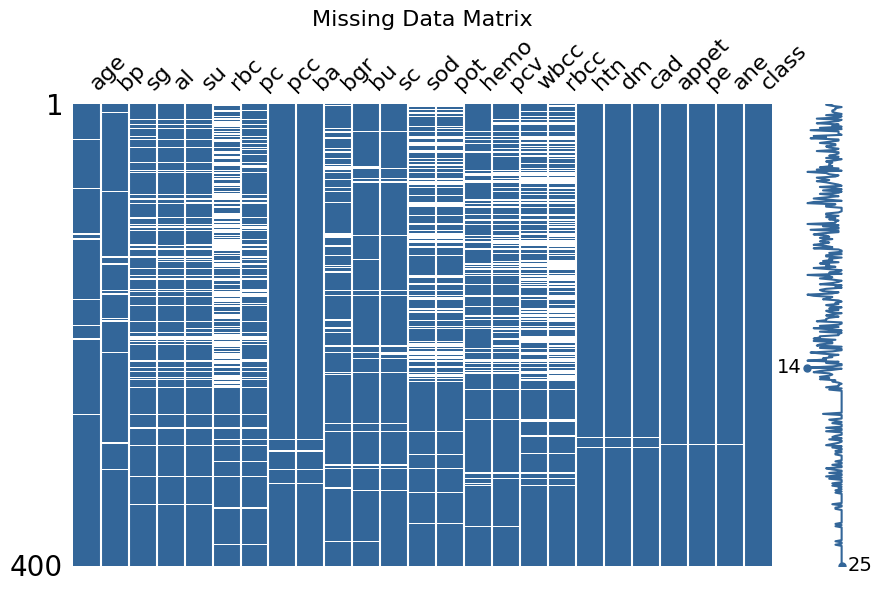


Percentage of missing values per feature:
rbc      38.00
rbcc     32.75
wbcc     26.50
pot      22.00
sod      21.75
pcv      17.75
pc       16.25
hemo     13.00
su       12.25
sg       11.75
al       11.50
bgr      11.00
bu        4.75
sc        4.25
bp        3.00
age       2.25
pcc       1.00
ba        1.00
htn       0.50
dm        0.50
cad       0.50
appet     0.25
pe        0.25
ane       0.25
dtype: float64


In [6]:
# Visualize missing data patterns
msno.matrix(df, figsize=(10, 6), color=(0.2, 0.4, 0.6))
plt.title("Missing Data Matrix", fontsize=16)
plt.show()

# Print exact percentages of missing data
missing_percentages = (df.isnull().sum() / len(df)) * 100
print("\nPercentage of missing values per feature:")
print(missing_percentages[missing_percentages > 0].sort_values(ascending=False))

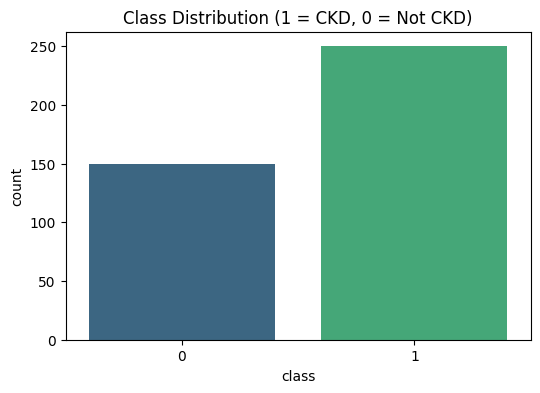


Exact Class Breakdown:
class
1    0.625
0    0.375
Name: proportion, dtype: float64


In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', hue='class', palette='viridis', legend=False)
plt.title('Class Distribution (1 = CKD, 0 = Not CKD)')
plt.show()

print("\nExact Class Breakdown:")
print(df['class'].value_counts(normalize=True))

Generating Distributions...


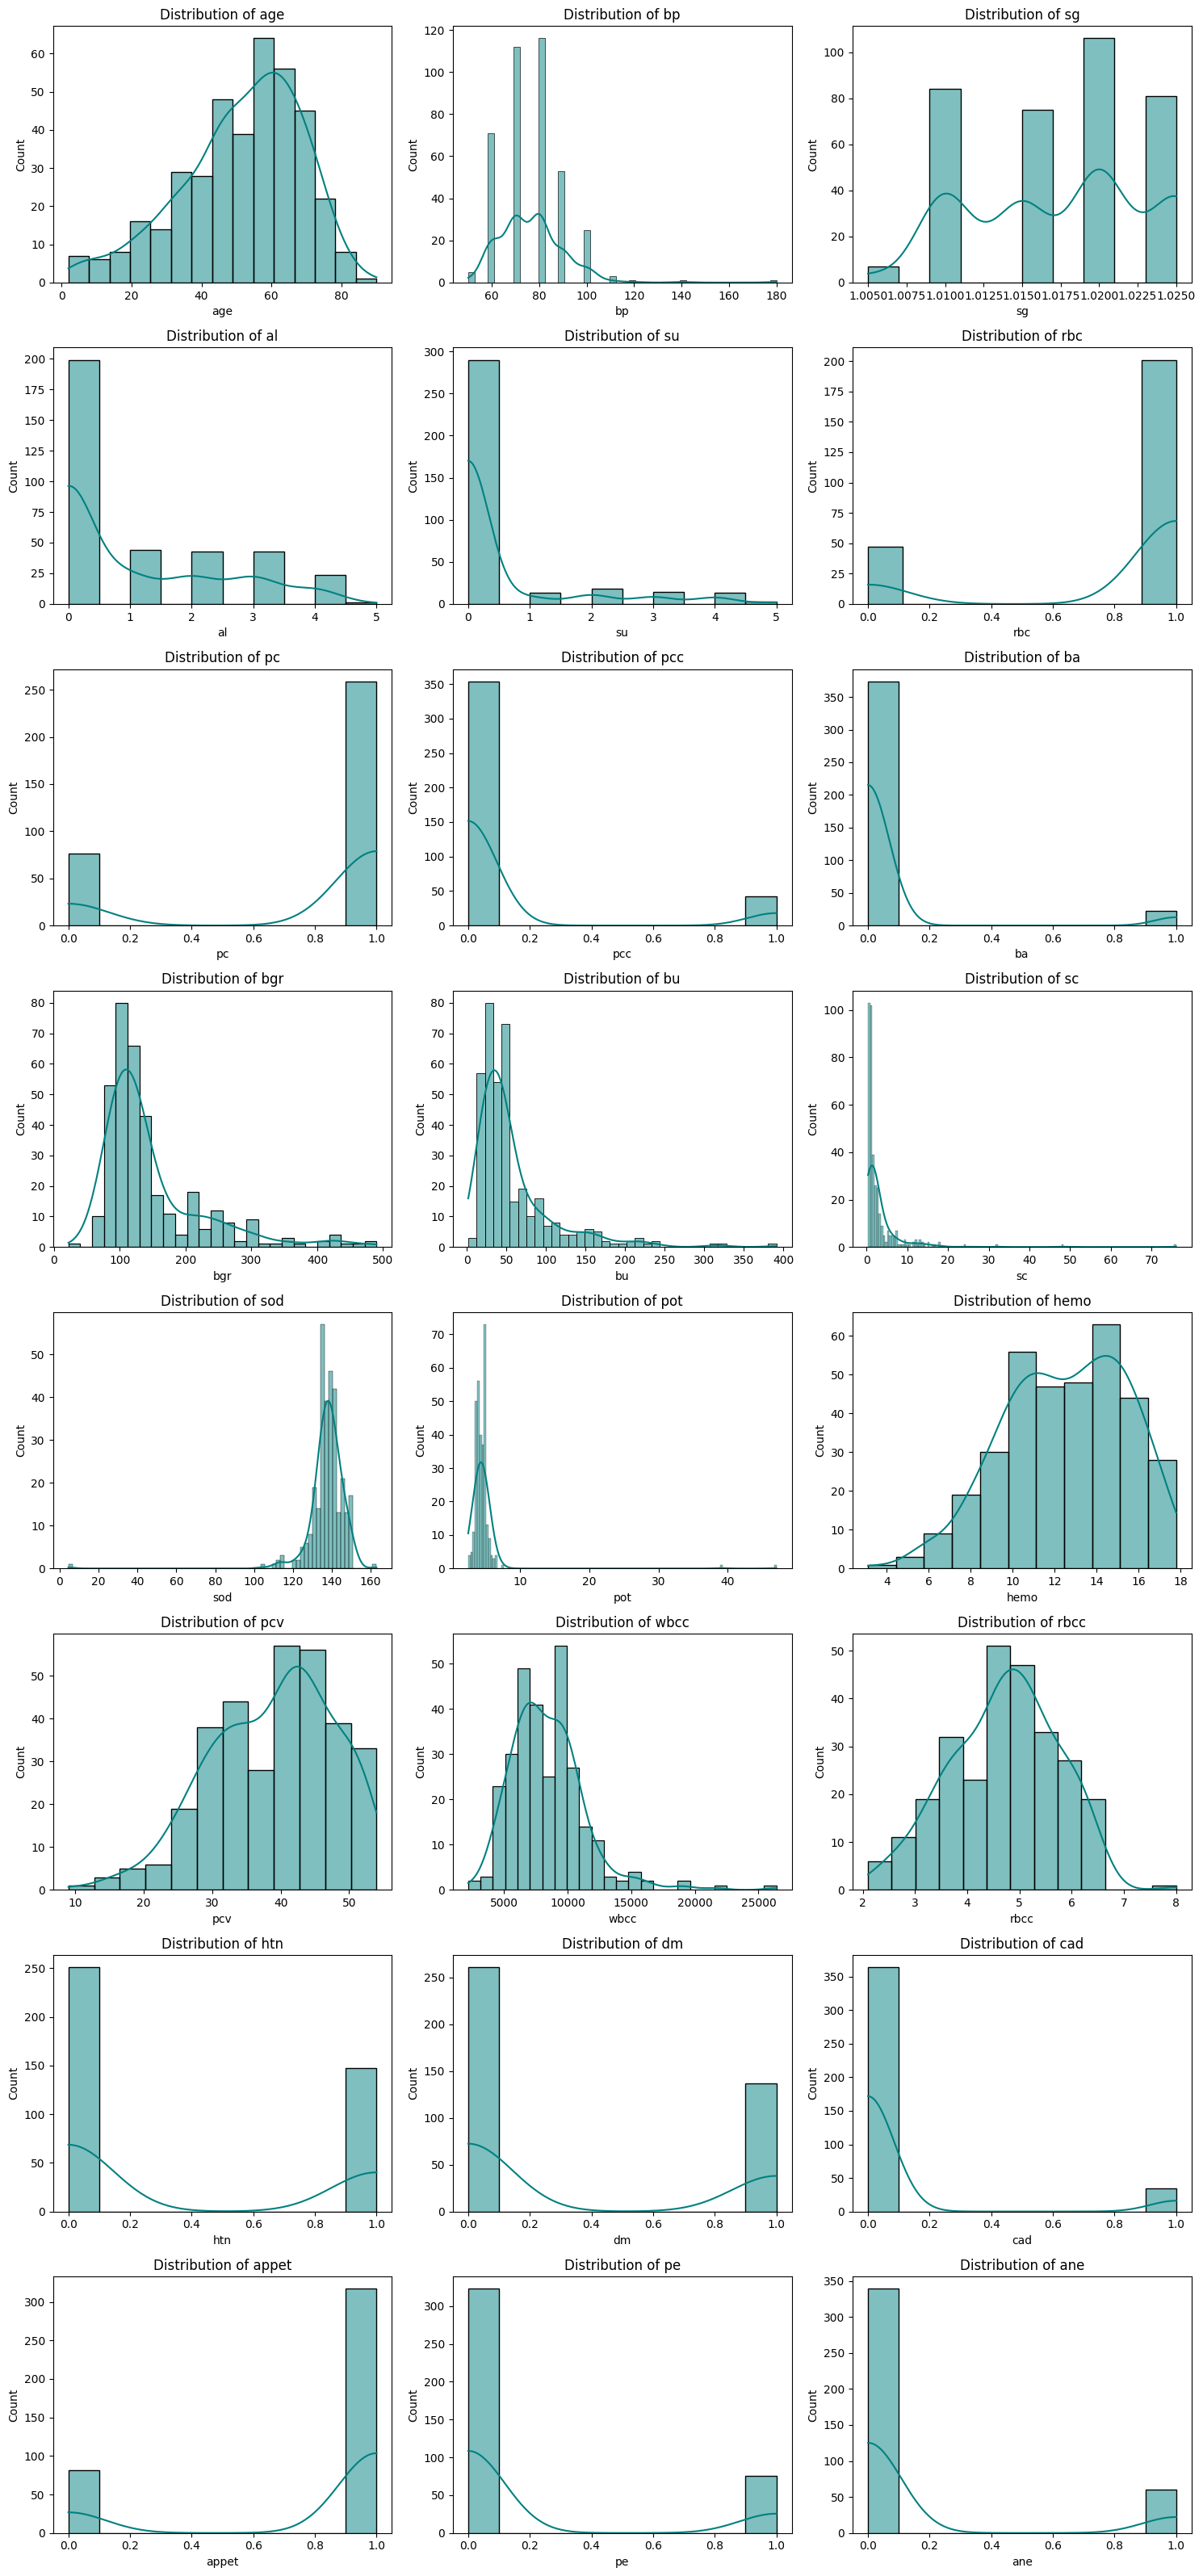


Generating Boxplots for Outlier Detection...


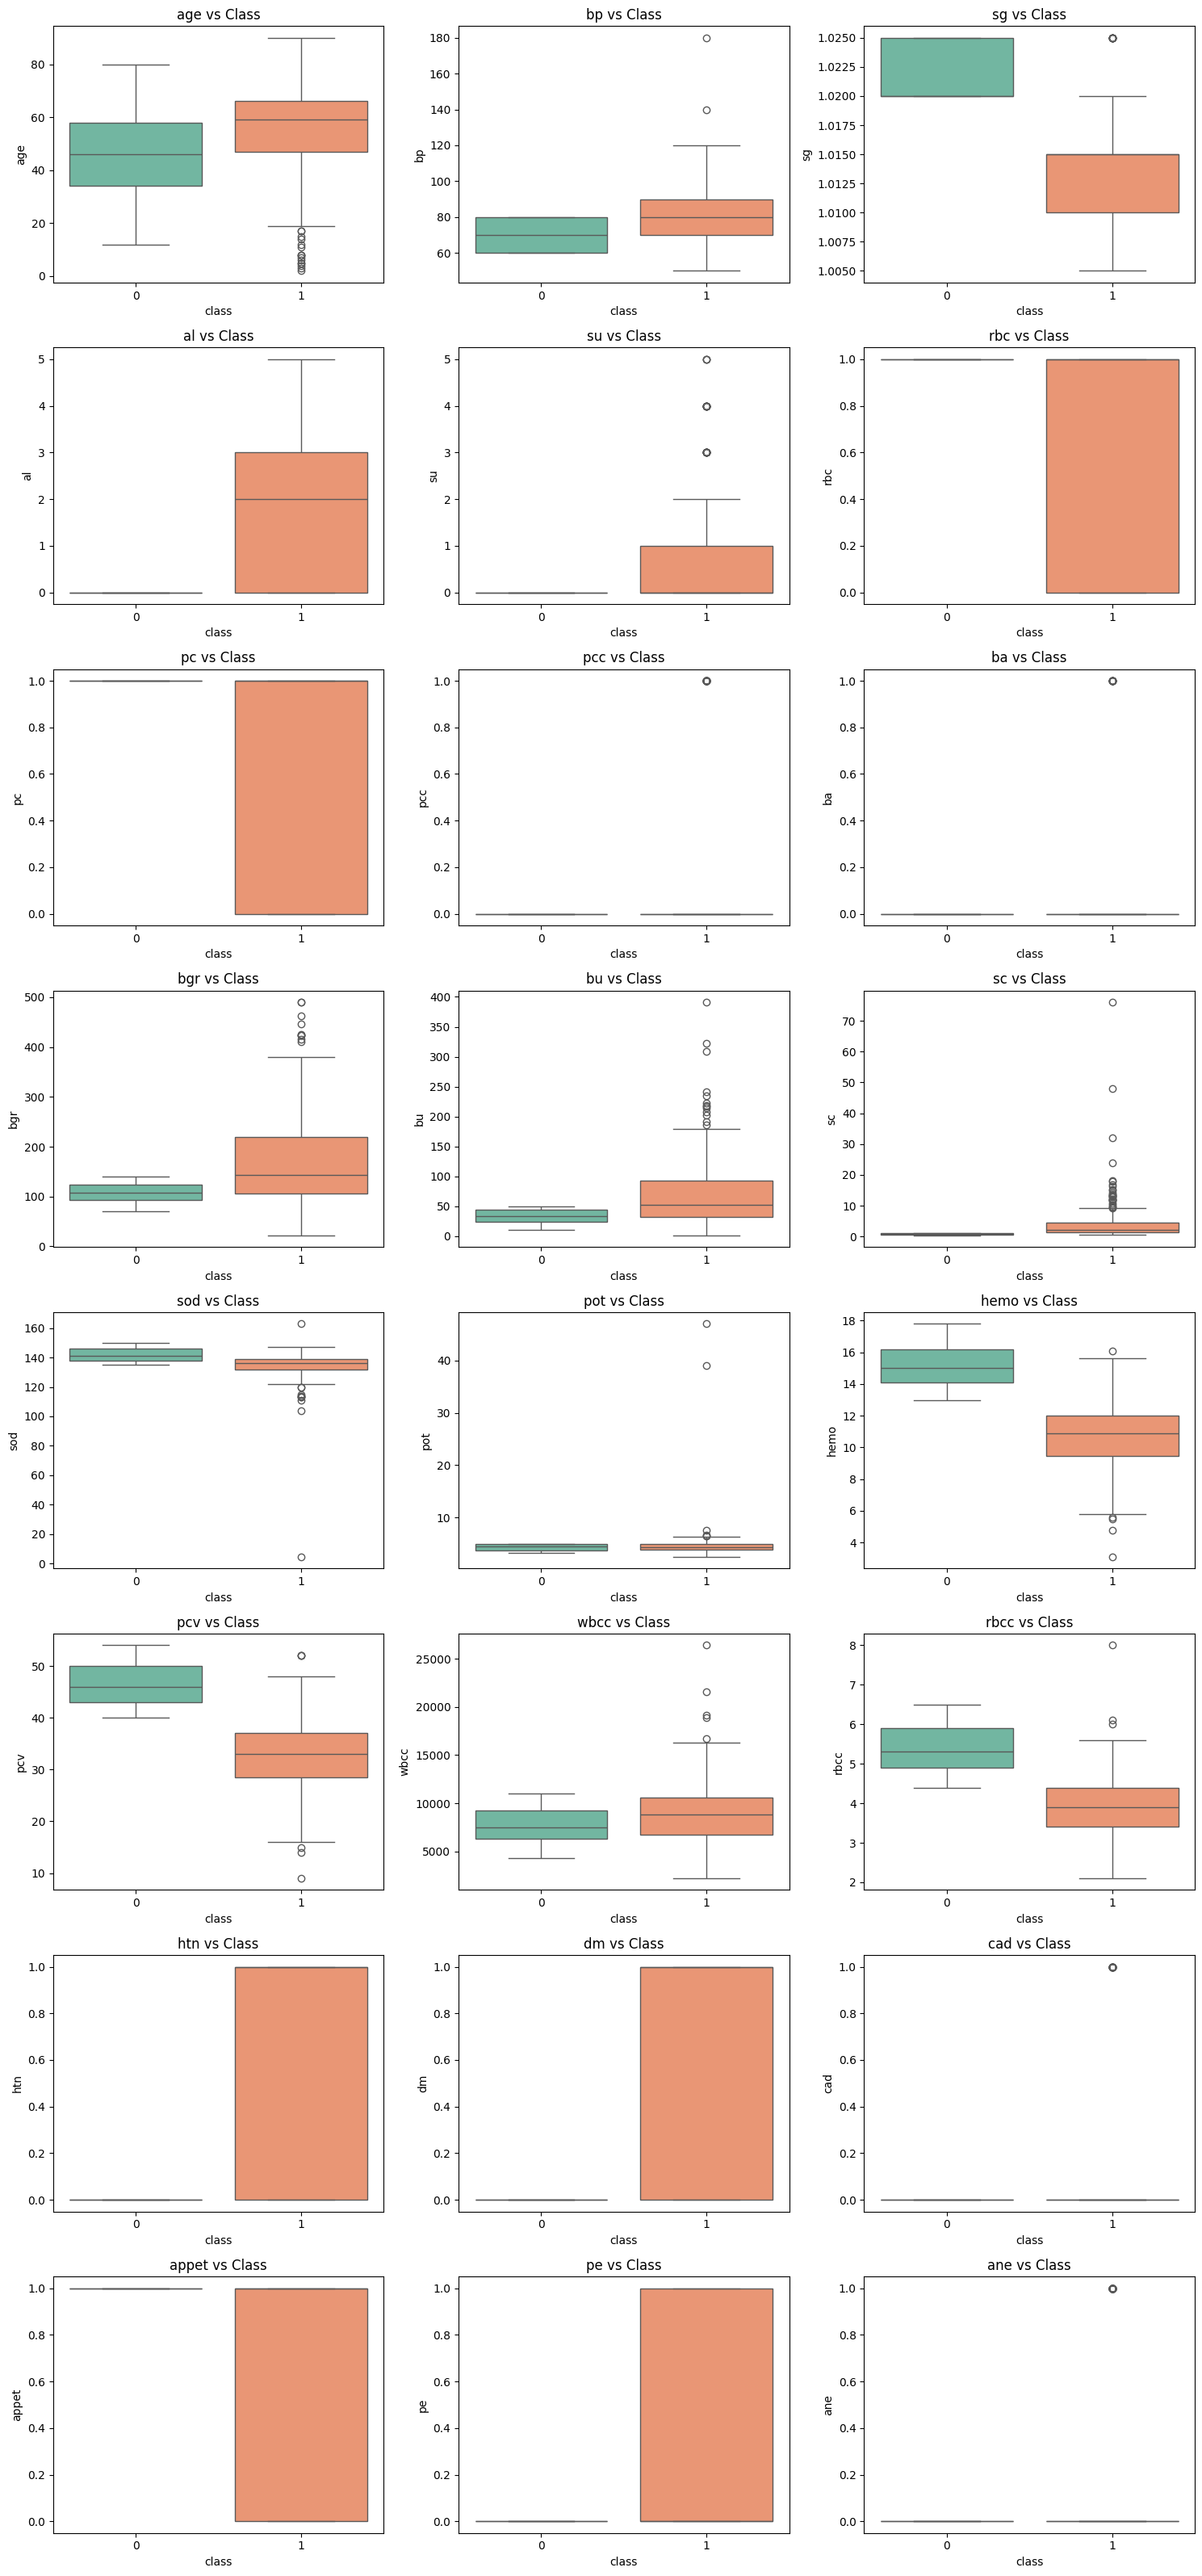

In [9]:
# Separate numeric features
numeric_features = df.select_dtypes(include=[np.number]).drop('class', axis=1).columns

# Calculate appropriate nrows
num_features = len(numeric_features)
ncols = 3 # Keep number of columns consistent
nrows = (num_features + ncols - 1) // ncols # Ceiling division

# 1. Histograms
print("Generating Distributions...")
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.histplot(df[col], kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 2. Boxplots
print("\nGenerating Boxplots for Outlier Detection...")
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    sns.boxplot(y=df[col], x=df['class'], hue=df['class'], ax=axes[i], palette='Set2', legend=False)
    axes[i].set_title(f'{col} vs Class')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()